# Handling Mixed Variables

Handling Mixed Variables sits squarely within the **Data Preprocessing and Feature Engineering** phase of the data science lifecycle. It is a critical step in the Data Preparation pipeline, occurring after initial data cleaning (like handling missing values) but before feeding data into a machine learning model.



## 🗺️ Where It Fits in the Data Science Roadmap

To see exactly where this topic lives, look at the standard data science workflow:

1. Data Collection (Gathering raw data)
2. Data Cleaning (Fixing missing values, removing duplicates)
3. **Data Preprocessing & Feature Engineering** 👈 **WE ARE HERE**
   - Handling Categorical Variables
   - Handling Continuous Variables
   - Handling Mixed Variables
   - Feature Scaling & Normalization
4. Model Training (Feeding processed data into algorithms)
5. Model Evaluation & Deployment



## 🔍 What is a Mixed Variable?

A **mixed variable** is a single feature (column) in a dataset that contains both **numeric** and **categorical** data within the same column, or strings that contain numbers with structured meaning.

Machine learning algorithms only understand numbers, but they cannot interpret mixed formats directly. Here are the three main types of mixed variables you will encounter:

### Types of Mixed Variables

### 1. Numbers and Labels Mixed Together

A column contains numbers for some records and text labels for others.

- **Example:** Financial credit history columns.
- `1, 2, 3` (representing the number of missed payments)
- `D` (Debt written off)
- `M` (Missing data/No history available)



### 2. Numbers Combined with Text/Units

A column contains numeric values but they are packaged as strings with units or identifiers.

- **Example 1:** Ticket numbers or open-text codes like `A/5 21171`, `PC 17599`, or `113803`.
- **Example 2:** Physical measurements stored as strings like `150 lbs`, `70 kg`, or `5.5 inches`.



### 3. Date and Time Components

While often treated as their own class, raw timestamps are inherently mixed because they contain numeric counts (days, years) tied to categorical contexts (months, days of the week, AM/PM).


## ⚠️ Why Mixed Variables Break Models

If we try to pass a mixed variable directly into a standard machine learning model (like a linear regression or a support vector machine), our code won't be able to interpret the data correctly. It will crash with a `ValueError` because it cannot convert strings to floats.

Even if we use models that handle categories natively (like LightGBM or CatBoost), they will treat the entire column as categorical. This completely destroys the mathematical relationships of the numerical parts (e.g., treating `150 lbs` and `151 lbs` as entirely independent categories rather than sequential numbers).

---

# How to Handle Mixed Variables!

To handle mixed variables, you must transform them into purely numeric formats that machine learning algorithms can understand. The two primary engineering strategies are splitting the variable into multiple distinct columns or mapping the labels to meaningful numeric values.



## 🛠️ The 4 Core Engineering Techniques

### 1. Split into Numeric and Categorical Columns
This is the most common approach for variables that combine numbers and characters in a single string (like ticket or cabin codes). we can extract the text part into a new categorical column and the number part into a modern numeric column.

- **Example:** Ticket: `PC 17599`
- **Result:** `Ticket_letters`: `"PC"` and `Ticket_numbers`: `17599`



### 2. Create an "Is_Label" Binary Indicator
For columns where a specific string acts as a special marker (like "Missing" or "Debt Written Off") alongside standard numeric counts, we can extract the string into a boolean flag.

- **Example:** A column with values `1, 2, D` (Debt written off).

- **Result:**
  - **Column 1 (Numeric):** `1, 2, NaN` (The text is replaced with a null value or imputed).
  - **Column 2 (Binary Indicator):** `Is_Debt_Written_Off` (`0, 0, 1`).



### 3. String Stripping & Type Casting
For numeric data wrapped in text units, you programmatically strip out the non-numeric characters and cast the column into a float or integer.

- **Example:** Weight: `"150 lbs"`
- **Result:** Weight: `150` (Data type changed from string object to float).



### 4. Impute Text Labels with Numerical Metrics
If a text label represents a specific state, you can replace that label with a statistical summary of the rest of the numerical data (like the median or mean) so the column remains entirely numeric.

- **Example:** Replacing `M` (Missing) in a payments column with `-1` or the median value `0`.

---

## 📊 Cleaned Output

After running the script, the data is perfectly structured for machine learning:

| ticket_num | ticket_cat | is_debt_written_off | missed_payments_clean | weight_lbs |
|------------|------------|----------------------|------------------------|------------|
| 21171.0    | A/5        | 0                    | 1.0                    | 150.0      |
| 17599.0    | PC         | 0                    | 2.0                    | 175.0      |
| 113803.0   | Missing    | 1                    | 0.0                    | 200.0      |
| 34282.0    | A/4        | 0                    | 0.0                    | 165.0      |

> **Note:** The `ticket_cat` column can now be fed into standard One-Hot Encoding or Label Encoding algorithms.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../../data/titanic_toy.csv")
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


### Handling 'number' Column

In [5]:
# Unique Values 
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

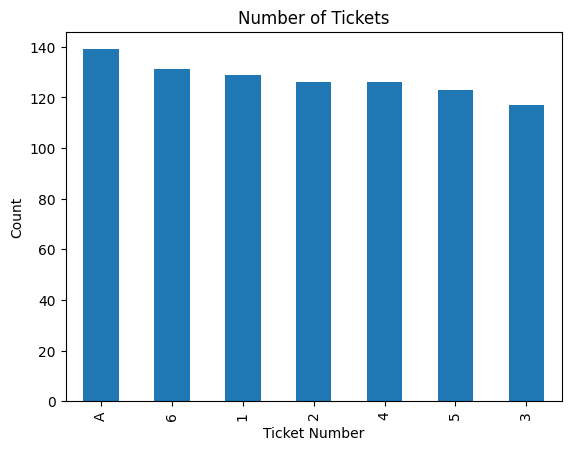

In [6]:
# Bar plot 
fig = df['number'].value_counts().plot(kind='bar')
plt.title('Number of Tickets')
plt.xlabel('Ticket Number')
plt.ylabel('Count')
plt.show()

In [7]:
# Extract Numerical Part 
df['Numerical_number'] = pd.to_numeric(df['number'], errors='coerce', downcast='integer')

# Extract Categorical Part 
df['Catergorical_number'] = np.where(df['Numerical_number'].isnull(), df['number'], np.nan)

df.head()

,Cabin,Ticket,number,Survived,Numerical_number,Catergorical_number
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


### Handling 'Cabin' Column

In [8]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [9]:
# Extract Numerical Part
df['Cabin_num'] = df['Cabin'].str.extract(r"(\d+)", expand=False)  

# Extract first letter
df['Cabin_cat'] = df['Cabin'].str[0]

df.head()

,Cabin,Ticket,number,Survived,Numerical_number,Catergorical_number,Cabin_num,Cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


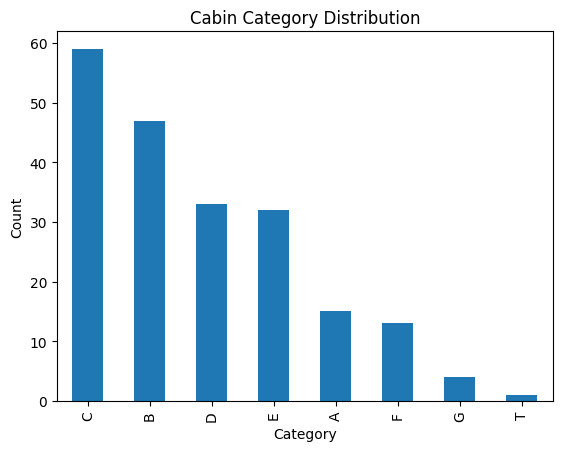

In [10]:
df['Cabin_cat'].value_counts().plot(kind='bar')
plt.title('Cabin Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

### Handling 'Ticket' Column

In [11]:
df.head()

,Cabin,Ticket,number,Survived,Numerical_number,Catergorical_number,Cabin_num,Cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [12]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [13]:
# Extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors = 'coerce', downcast='integer')

# Extracting the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])


df.head()

,Cabin,Ticket,number,Survived,Numerical_number,Catergorical_number,Cabin_num,Cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
